# Alumni Events Dashboard Setup Notebook

Notebook ini dibuat supaya kamu bisa **Run All sekali** untuk:

1. install dependency dasar,
2. membangun database SQLite dari `uts_dump.sql`,
3. extract arsip `vouching.zip`,
4. preview data untuk 3 fitur ujian,
5. menampilkan mockup UI/UX untuk menu **Tiket & Order**.

Setelah selesai, jalankan:

```bash
streamlit run app.py
```

> Letakkan notebook ini, `app.py`, `uts_dump.sql`, dan `vouching.zip` dalam folder yang sama.


In [1]:
%pip install -q pandas pillow qrcode[pil] streamlit

zsh:1: no matches found: qrcode[pil]
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import re
import sqlite3
import zipfile
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

BASE_DIR = Path.cwd()
SQL_PATH = BASE_DIR / "uts_dump.sql"
ZIP_PATH = BASE_DIR / "vouching.zip"
DB_PATH = BASE_DIR / "alumnievents.db"
VOUCHING_DIR = BASE_DIR / "vouching"

assert SQL_PATH.exists(), f"File tidak ditemukan: {SQL_PATH}"
print("SQL source:", SQL_PATH)
print("Zip source:", ZIP_PATH if ZIP_PATH.exists() else "Tidak ada zip, skip extract")

SQL source: /Users/phantom/Downloads/second attempt/uts_dump.sql
Zip source: /Users/phantom/Downloads/second attempt/vouching.zip


In [3]:
def split_rows(values_block: str):
    rows = []
    depth = 0
    in_quote = False
    escape = False
    start = None

    for i, ch in enumerate(values_block):
        if in_quote:
            if escape:
                escape = False
            elif ch == "\\": 
                escape = True
            elif ch == "'":
                in_quote = False
        else:
            if ch == "'":
                in_quote = True
            elif ch == "(":
                if depth == 0:
                    start = i
                depth += 1
            elif ch == ")":
                depth -= 1
                if depth == 0 and start is not None:
                    rows.append(values_block[start:i+1])
                    start = None
    return rows


def parse_sql_tuple(row_text: str):
    inner = row_text[1:-1]
    values = []
    current = []
    in_quote = False
    escape = False

    for ch in inner:
        if in_quote:
            current.append(ch)
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == "'":
                in_quote = False
        else:
            if ch == "'":
                in_quote = True
                current.append(ch)
            elif ch == ",":
                values.append("".join(current).strip())
                current = []
            else:
                current.append(ch)
    values.append("".join(current).strip())

    def convert(token: str):
        if token.upper() == "NULL":
            return None
        if token.startswith("'") and token.endswith("'"):
            return token[1:-1].replace("\\'", "'").replace("\\\\", "\\")
        if re.fullmatch(r"-?\d+", token):
            return int(token)
        if re.fullmatch(r"-?\d+\.\d+", token):
            return float(token)
        return token

    return tuple(convert(v) for v in values)


def extract_insert_rows(sql_text: str, table_name: str):
    match = re.search(rf"INSERT INTO `{re.escape(table_name)}` VALUES (.*?);", sql_text, re.S)
    if not match:
        raise ValueError(f"INSERT untuk tabel {table_name} tidak ditemukan")
    rows = split_rows(match.group(1))
    return [parse_sql_tuple(row) for row in rows]


def build_database_from_sql(sql_path: Path, db_path: Path):
    sql_text = sql_path.read_text(encoding="utf-8")

    tables = [
        "alumni_users",
        "alumni_boards",
        "events",
        "event_participants",
        "merch_orders",
        "merch_order_status_history",
    ]

    schema = """
    PRAGMA foreign_keys = ON;

    CREATE TABLE alumni_users (
      user_id INTEGER PRIMARY KEY,
      full_name TEXT,
      email TEXT,
      role TEXT,
      member_type TEXT,
      member_id TEXT UNIQUE,
      graduation_year INTEGER,
      company TEXT
    );

    CREATE TABLE alumni_boards (
      board_id INTEGER PRIMARY KEY,
      user_id INTEGER NOT NULL,
      position TEXT NOT NULL,
      start_year INTEGER NOT NULL,
      end_year INTEGER NOT NULL,
      is_active INTEGER DEFAULT 1,
      FOREIGN KEY (user_id) REFERENCES alumni_users(user_id)
    );

    CREATE TABLE events (
      event_id INTEGER PRIMARY KEY,
      event_name TEXT,
      description TEXT,
      start_date TEXT,
      max_quota INTEGER,
      ticket_price REAL,
      type_id INTEGER,
      location_id INTEGER
    );

    CREATE TABLE event_participants (
      participant_id INTEGER PRIMARY KEY,
      user_id INTEGER,
      event_id INTEGER,
      registration_date TEXT,
      qr_code TEXT,
      attendance_status INTEGER DEFAULT 0,
      FOREIGN KEY (user_id) REFERENCES alumni_users(user_id),
      FOREIGN KEY (event_id) REFERENCES events(event_id)
    );

    CREATE TABLE merch_orders (
      order_id INTEGER PRIMARY KEY,
      user_id INTEGER NOT NULL,
      event_id INTEGER,
      vending_machine_id TEXT,
      order_date TEXT,
      pickup_time TEXT,
      total_price REAL,
      order_status TEXT,
      FOREIGN KEY (user_id) REFERENCES alumni_users(user_id),
      FOREIGN KEY (event_id) REFERENCES events(event_id)
    );

    CREATE TABLE merch_order_status_history (
      history_id INTEGER PRIMARY KEY,
      order_id INTEGER NOT NULL,
      old_status TEXT,
      new_status TEXT NOT NULL,
      changed_at TEXT,
      notes TEXT,
      FOREIGN KEY (order_id) REFERENCES merch_orders(order_id) ON DELETE CASCADE
    );
    """

    if db_path.exists():
        db_path.unlink()

    with sqlite3.connect(db_path) as conn:
        conn.executescript(schema)
        for table in tables:
            rows = extract_insert_rows(sql_text, table)
            placeholders = ",".join(["?"] * len(rows[0]))
            conn.executemany(f"INSERT INTO {table} VALUES ({placeholders})", rows)
        conn.commit()


def extract_vouching(zip_path: Path, target_dir: Path):
    if not zip_path.exists():
        return
    target_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(target_dir)

In [4]:
build_database_from_sql(SQL_PATH, DB_PATH)
extract_vouching(ZIP_PATH, VOUCHING_DIR)

with sqlite3.connect(DB_PATH) as conn:
    counts = {
        "alumni_users": pd.read_sql_query("SELECT COUNT(*) AS n FROM alumni_users", conn)["n"][0],
        "alumni_boards": pd.read_sql_query("SELECT COUNT(*) AS n FROM alumni_boards", conn)["n"][0],
        "events": pd.read_sql_query("SELECT COUNT(*) AS n FROM events", conn)["n"][0],
        "event_participants": pd.read_sql_query("SELECT COUNT(*) AS n FROM event_participants", conn)["n"][0],
        "merch_orders": pd.read_sql_query("SELECT COUNT(*) AS n FROM merch_orders", conn)["n"][0],
        "merch_order_status_history": pd.read_sql_query("SELECT COUNT(*) AS n FROM merch_order_status_history", conn)["n"][0],
    }

print("Database berhasil dibuat:", DB_PATH)
print("Folder vouching:", VOUCHING_DIR if VOUCHING_DIR.exists() else "tidak ada")
counts

Database berhasil dibuat: /Users/phantom/Downloads/second attempt/alumnievents.db
Folder vouching: /Users/phantom/Downloads/second attempt/vouching


{'alumni_users': np.int64(320),
 'alumni_boards': np.int64(15),
 'events': np.int64(18),
 'event_participants': np.int64(1991),
 'merch_orders': np.int64(1362),
 'merch_order_status_history': np.int64(2810)}

In [5]:
with sqlite3.connect(DB_PATH) as conn:
    print("=== Preview 1: Board Management ===")
    display(pd.read_sql_query(
        """
        SELECT
            ab.board_id,
            au.full_name,
            ab.position,
            ab.start_year,
            ab.end_year,
            CASE WHEN ab.is_active = 1 THEN 'Aktif' ELSE 'Demisioner' END AS status
        FROM alumni_boards ab
        JOIN alumni_users au ON au.user_id = ab.user_id
        ORDER BY ab.end_year DESC, ab.position ASC
        """,
        conn
    ))

    print("=== Preview 2: Audit Transaksi (20 order terbaru) ===")
    display(pd.read_sql_query(
        """
        SELECT
            mo.order_id,
            mo.order_date,
            au.full_name,
            e.event_name,
            mo.order_status,
            mo.vending_machine_id,
            mo.total_price
        FROM merch_orders mo
        JOIN alumni_users au ON au.user_id = mo.user_id
        LEFT JOIN events e ON e.event_id = mo.event_id
        ORDER BY mo.order_date DESC, mo.order_id DESC
        LIMIT 20
        """,
        conn
    ))

    print("=== Preview 3: Tiket Saya (20 participant terbaru) ===")
    display(pd.read_sql_query(
        """
        SELECT
            ep.participant_id,
            au.full_name,
            e.event_name,
            ep.qr_code,
            ep.attendance_status,
            ep.registration_date
        FROM event_participants ep
        JOIN alumni_users au ON au.user_id = ep.user_id
        JOIN events e ON e.event_id = ep.event_id
        ORDER BY ep.registration_date DESC, ep.participant_id DESC
        LIMIT 20
        """,
        conn
    ))

=== Preview 1: Board Management ===


,board_id,full_name,position,start_year,end_year,status
0,15,Adhitya Santoso Yulianto,Head of E-Commerce,2024,2027,Aktif
1,14,Bunga Setiawan,Head of Events,2024,2027,Aktif
2,11,Ahmad Sanjaya Sasmita,President,2024,2027,Aktif
3,12,Ahmad Ramadhan Nasution,Secretary,2024,2027,Aktif
4,13,Bunga Lestari,Treasurer,2024,2027,Aktif
5,10,Bunga Mulyani Hermawan,Head of E-Commerce,2021,2024,Demisioner
6,9,Adhitya Baskoro,Head of Events,2021,2024,Demisioner
7,6,Adhitya Purnama,President,2021,2024,Demisioner
8,7,Ahmad Wibowo,Secretary,2021,2024,Demisioner
9,8,Ahmad Hartono,Treasurer,2021,2024,Demisioner


=== Preview 2: Audit Transaksi (20 order terbaru) ===


,order_id,order_date,full_name,event_name,order_status,vending_machine_id,total_price
0,11968,2027-11-19 11:00:00,Mira Sari,Grand Alumni Homecoming 2027,Completed,VM-01,1195179.0
1,11951,2027-11-19 11:00:00,Erwin Nugroho,Grand Alumni Homecoming 2027,Completed,VM-03,1766100.0
2,11950,2027-11-19 11:00:00,Laras Sari,Grand Alumni Homecoming 2027,Completed,VM-02,3049869.0
3,11942,2027-11-19 11:00:00,Hasan Puspita Widjojo,Grand Alumni Homecoming 2027,Completed,VM-03,3049869.0
4,11936,2027-11-19 11:00:00,Erwin Siregar,Grand Alumni Homecoming 2027,Completed,VM-03,1711038.0
5,11935,2027-11-19 11:00:00,Rizky Cahyono Haryanto,Grand Alumni Homecoming 2027,Completed,VM-02,1369527.0
6,11925,2027-11-19 11:00:00,Bunga Mulyani Hermawan,Grand Alumni Homecoming 2027,Completed,VM-03,1451034.0
7,11909,2027-11-19 11:00:00,Naufal Tanjung Pambudi,Grand Alumni Homecoming 2027,Completed,VM-03,2378446.0
8,11906,2027-11-19 11:00:00,Pandu Fitriani Yulianto,Grand Alumni Homecoming 2027,Completed,VM-03,1250241.0
9,11905,2027-11-19 11:00:00,Farah Nugroho Putri,Grand Alumni Homecoming 2027,Completed,VM-01,1735310.0


=== Preview 3: Tiket Saya (20 participant terbaru) ===


,participant_id,full_name,event_name,qr_code,attendance_status,registration_date
0,2191,Naufal Mulyani Mulyono,Grand Alumni Homecoming 2027,QR-3C83C31C,0,2027-11-19 11:00:00
1,2092,Gilang Gunawan Baharudin,Grand Alumni Homecoming 2027,QR-DB4E203E,0,2027-11-19 11:00:00
2,1977,Jamal Puspita Wicaksono,Grand Alumni Homecoming 2027,QR-18A54826,0,2027-11-19 11:00:00
3,1936,Laras Ramadhan Yulianto,Grand Alumni Homecoming 2027,QR-BD9F097C,0,2027-11-19 11:00:00
4,2213,Farah Sanjaya,Grand Alumni Homecoming 2027,QR-4AB1C697,0,2027-11-18 11:00:00
5,2203,Nadia Kusuma,Grand Alumni Homecoming 2027,QR-F45AC700,0,2027-11-18 11:00:00
6,2185,Erwin Lestari Utama,Grand Alumni Homecoming 2027,QR-F4850D0E,0,2027-11-18 11:00:00
7,2154,Dian Wijaya Ramadhan,Grand Alumni Homecoming 2027,QR-D6F042F5,0,2027-11-18 11:00:00
8,2116,Siti Sanjaya,Grand Alumni Homecoming 2027,QR-752B25E6,0,2027-11-18 11:00:00
9,1926,Farah Kusuma Baharudin,Grand Alumni Homecoming 2027,QR-7AFA71CA,0,2027-11-18 11:00:00


In [6]:
with sqlite3.connect(DB_PATH) as conn:
    sample_order = pd.read_sql_query(
        """
        SELECT mo.order_id
        FROM merch_orders mo
        JOIN merch_order_status_history h ON h.order_id = mo.order_id
        GROUP BY mo.order_id
        HAVING COUNT(h.history_id) >= 2
        ORDER BY mo.order_id
        LIMIT 1
        """,
        conn
    )["order_id"].iloc[0]

    print(f"=== Timeline contoh untuk order_id {sample_order} ===")
    display(pd.read_sql_query(
        """
        SELECT old_status, new_status, changed_at, notes
        FROM merch_order_status_history
        WHERE order_id = ?
        ORDER BY changed_at ASC, history_id ASC
        """,
        conn,
        params=(int(sample_order),)
    ))

=== Timeline contoh untuk order_id 10003 ===


,old_status,new_status,changed_at,notes
0,New Order,Paid,2024-01-31 02:00:00,Sistem: Pembayaran berhasil dikonfirmasi
1,Paid,Completed,2024-02-10 04:00:00,Sistem: Barang berhasil diambil di VM-01


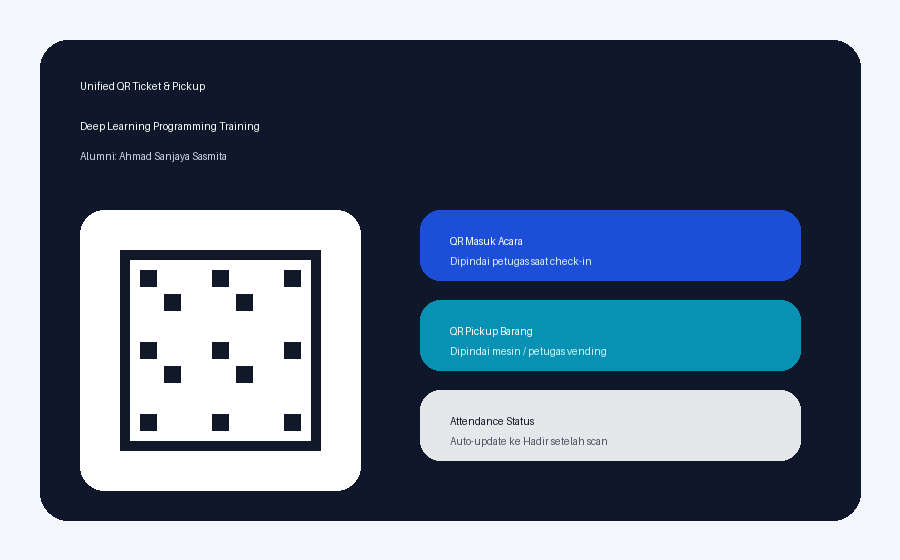

In [7]:
def create_ticket_mockup():
    width, height = 900, 560
    img = Image.new("RGB", (width, height), "#f3f6fb")
    draw = ImageDraw.Draw(img)

    draw.rounded_rectangle((40, 40, 860, 520), radius=28, fill="#0f172a")
    draw.text((80, 80), "Unified QR Ticket & Pickup", fill="white")
    draw.text((80, 120), "Deep Learning Programming Training", fill="white")
    draw.text((80, 150), "Alumni: Ahmad Sanjaya Sasmita", fill="#cbd5e1")

    draw.rounded_rectangle((80, 210, 360, 490), radius=24, fill="white")
    draw.rectangle((120, 250, 320, 450), outline="#111827", width=10)

    for y in range(0, 7):
        for x in range(0, 7):
            if (x * y + x + y) % 3 == 0:
                x0 = 140 + x * 24
                y0 = 270 + y * 24
                draw.rectangle((x0, y0, x0 + 16, y0 + 16), fill="#111827")

    draw.rounded_rectangle((420, 210, 800, 280), radius=20, fill="#1d4ed8")
    draw.text((450, 235), "QR Masuk Acara", fill="white")
    draw.text((450, 255), "Dipindai petugas saat check-in", fill="#dbeafe")

    draw.rounded_rectangle((420, 300, 800, 370), radius=20, fill="#0891b2")
    draw.text((450, 325), "QR Pickup Barang", fill="white")
    draw.text((450, 345), "Dipindai mesin / petugas vending", fill="#cffafe")

    draw.rounded_rectangle((420, 390, 800, 460), radius=20, fill="#e5e7eb")
    draw.text((450, 415), "Attendance Status", fill="#111827")
    draw.text((450, 435), "Auto-update ke Hadir setelah scan", fill="#4b5563")

    return img

mockup = create_ticket_mockup()
display(mockup)

In [8]:
print("Selesai.")
print("Langkah berikutnya:")
print("1. Pastikan file app.py ada di folder yang sama.")
print("2. Jalankan command berikut di terminal:")
print()
print("   streamlit run app.py")

Selesai.
Langkah berikutnya:
1. Pastikan file app.py ada di folder yang sama.
2. Jalankan command berikut di terminal:

   streamlit run app.py
